In [9]:
# Problem: Predict house prices with XGBoost
# Dataset: https://www.kaggle.com/datasets/shashanknecrothapa/ames-housing-dataset

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost
import warnings

In [3]:
# Step 1: Load the data
data = pd.read_csv('AmesHousing.csv')
print(data)

      Order        PID  MS SubClass MS Zoning  Lot Frontage  Lot Area Street  \
0         1  526301100           20        RL         141.0     31770   Pave   
1         2  526350040           20        RH          80.0     11622   Pave   
2         3  526351010           20        RL          81.0     14267   Pave   
3         4  526353030           20        RL          93.0     11160   Pave   
4         5  527105010           60        RL          74.0     13830   Pave   
...     ...        ...          ...       ...           ...       ...    ...   
2925   2926  923275080           80        RL          37.0      7937   Pave   
2926   2927  923276100           20        RL           NaN      8885   Pave   
2927   2928  923400125           85        RL          62.0     10441   Pave   
2928   2929  924100070           20        RL          77.0     10010   Pave   
2929   2930  924151050           60        RL          74.0      9627   Pave   

     Alley Lot Shape Land Contour  ... 

In [4]:
# Step 2: Preprocess the data
# Handle missing values:
# Fill missing numerical values with the columns median
# Fill categorical vales with 'None'
# Encode the categorical data using One Hot Encoding

for col in data.columns:
    if data[col].dtypes in [np.int64, np.float64]:
        data[col].fillna(data[col].median(), inplace=True)
    else:
        data[col].fillna('None', inplace=True)

# One Hot Encoding used to encode the categorical data.
data_encoded = pd.get_dummies(data, drop_first=True)

# Define the target and feature sets.
X = data_encoded.drop('SalePrice', axis=1)
y = data_encoded['SalePrice']


C:\Users\muhid\AppData\Local\Temp\ipykernel_13904\1293091155.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[col].fillna(data[col].median(), inplace=True)
C:\Users\muhid\AppData\Local\Temp\ipykernel_13904\1293091155.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For 

In [5]:
# Step 3: Split the data.
# Split the data into 80% for training and 20% for validation.
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)


In [6]:
# Step 4: Build and Train the model.
model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
model.fit(X_train, y_train)


,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


In [7]:
# Step 5: Make prediction and Evaluate
predictions = model.predict(X_val)
mse = mean_squared_error(y_val, predictions)
rmse = np.sqrt(mse)
print("Root mean square error: ", rmse)

Root mean square error:  25706.08519397693


<Figure size 700x500 with 0 Axes>

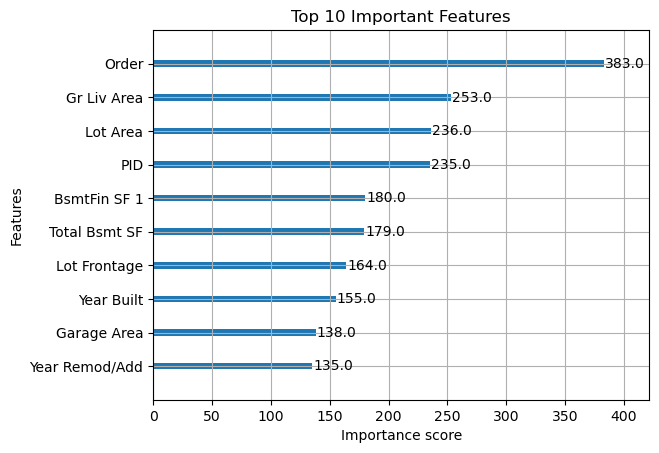

In [8]:
# Step 6: Visualization
# XGBoost provides a built-in method to plot feature importance, which can give insights into the most
# important features for predicting house prices.
plt.figure(figsize=(7, 5))
xgboost.plot_importance(model, max_num_features=10)
plt.title('Top 10 Important Features')
plt.show()